In [33]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_acceleration(csv_file):
    """
    Loads a CSV file and plots acceleration signals (X, Y, Z) over time.
    
    Parameters:
    csv_file (str): Path to the CSV file containing acceleration data.
    """
    # ==================== 1. Load the CSV File ====================
    df = pd.read_csv(csv_file)

    # Display basic dataset information (optional)
    #print(df.info())
    #print(df.head())

    # ==================== 2. Plot Raw Acceleration Signals ====================
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Plot acceleration for each axis
    axes[0].plot(df["Time (s)"], df["Acceleration x (m/s^2)"], label="X-axis", color='blue')
    axes[0].set_ylabel("Acceleration (m/s²)")
    axes[0].set_title("Acceleration X (with Gravity, Noise, and Drift)")
    axes[0].legend()

    axes[1].plot(df["Time (s)"], df["Acceleration y (m/s^2)"], label="Y-axis", color='green')
    axes[1].set_ylabel("Acceleration (m/s²)")
    axes[1].set_title("Acceleration Y (with Gravity, Noise, and Drift)")
    axes[1].legend()

    axes[2].plot(df["Time (s)"], df["Acceleration z (m/s^2)"], label="Z-axis", color='red')
    axes[2].set_ylabel("Acceleration (m/s²)")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Acceleration Z (with Gravity, Noise, and Drift)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

In [34]:
import pandas as pd
import os

def remove_gravity_and_save(csv_file):
    """
    Loads a CSV file, removes gravitational acceleration (flat surface assumption),
    and saves the corrected data while keeping all original columns.
    
    Parameters:
    csv_file (str): Path to the input CSV file.
    
    Returns:
    str: Path to the new CSV file with gravity removed.
    """
    # Load CSV file and normalize column names (strip spaces)
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip()  # Remove leading/trailing spaces

    # Check available column names
    expected_columns = ["Time (s)", "Acceleration x (m/s^2)", "Acceleration y (m/s^2)", 
                        "Acceleration z (m/s^2)", "Absolute acceleration (m/s^2)"]
    
    missing_columns = [col for col in expected_columns if col not in df.columns]
    if missing_columns:
        print(f"❌ ERROR: Missing columns in CSV file: {missing_columns}")
        print(f"Available columns: {list(df.columns)}")
        return None

    # Apply gravity correction only to the z-axis
    df["Acceleration z (m/s^2)"] = df["Acceleration z (m/s^2)"] - 9.81  

    # Generate new filename
    base_name = os.path.splitext(csv_file)[0]  # Remove ".csv" from filename
    new_filename = f"{base_name}_no_gravity.csv"

    # Save the corrected data with the same structure
    df.to_csv(new_filename, index=False, float_format="%.10f")

    print(f"✅ Gravity-corrected data saved as: {new_filename}")
    return new_filename

✅ Gravity-corrected data saved as: zig_zag_movement_rav_no_gravity.csv


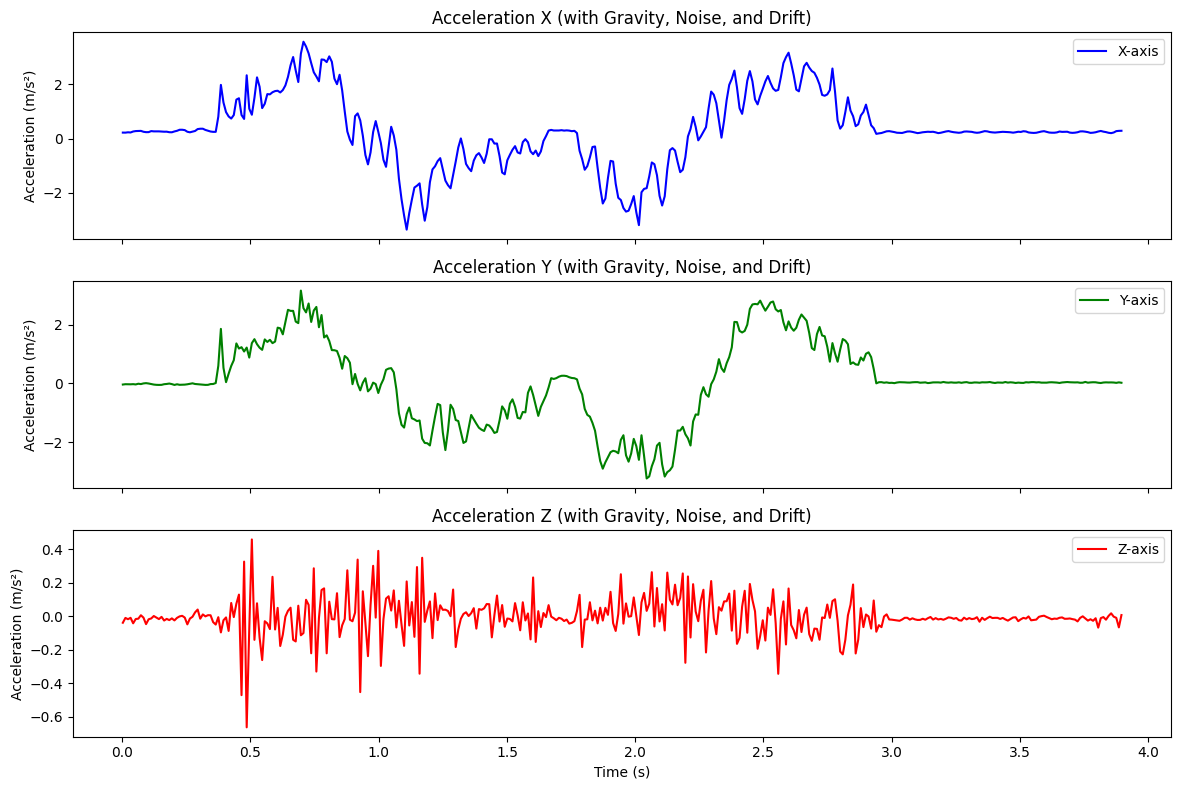

In [35]:
remove_gravity_and_save("zig_zag_movement.csv")
plot_acceleration("zig_zag_movement_no_gravity.csv")